# Data Filtering 

## Butterworth low, high, and bandpass filters 

### how it works

[SciPy reference](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html):scipy.signal.
butter

An alternative or supplement to digital smoothing of noisy data is digital filtering of that data. Three examples of particular interest from the [SciPy Cookbook](https://scipy-cookbook.readthedocs.io/items/idx_signal_processing.html) involve [**Butterworth filters**](https://en.wikipedia.org/wiki/Butterworth_filter),   which are designed to have as flat a frequency response as possible over the range of frequencies to be passed (while still filtering out unwanted frequencies at higher and/or lower frequencies). 

1. a Butterworth [bandpass filter](http://scipy-cookbook.readthedocs.io/items/ButterworthBandpass.html) to filter out all but an oscillating signal at a particular frequency 
2. a Butterworth [low pass filter](http://scipy-cookbook.readthedocs.io/items/FiltFilt.html) for general smooth of  high frequency noise
3. a Butterworth high pass filter to remove dc drift 

 

### implementation in Python

In [1]:
# first, we import some needed Python modules 
import numpy as np # only need this once per program
import matplotlib as mpl
from matplotlib import pyplot as plt 

# from scipy.signal import savgol_filter 
from scipy.signal import butter, lfilter
from scipy.signal import freqz

rng = np.random.default_rng() #rng stands for random number generator

## generate a noisy signal

In [2]:
# data sampling parameters
f_sampling = 5000 # data sampling frequency in Hz
Nyquist_frequency = f_sampling / 2 # max frequency that can be correctly measured at sampling frequency

In [3]:
T = 0.05
nsamples = int(T * f_sampling)
t = np.linspace(0, T, nsamples, endpoint=False)
a = 0.02
f0 = 600.0
x_clean = a * np.cos(2 * np.pi * f0 * t + .11)
x_noisy = np.copy(x_clean)
x_noisy +=  0.1 * np.sin(2 * np.pi * 1.2 * np.sqrt(t))
x_noisy += 0.01 * np.cos(2 * np.pi * 312 * t + 0.1)
x_noisy += 0.03 * np.cos(2 * np.pi * 2000 * t)

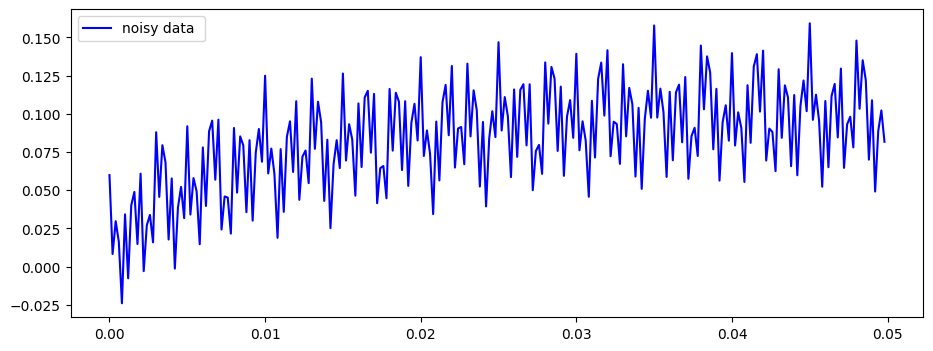

In [4]:
# make a plot

plt.figure(figsize = (11,4))                  #specify figure size as 7 x 5 inches
                                             #for default size, type plt.figure() 

# plot original data 
plt.plot(t, x_noisy, color = 'blue', label = 'noisy data ')
# plt.plot(t, x_filtered,  color = 'red', label = 'bandpass filter (%g Hz - %g Hz)' % (low_pass,high_pass ))
plt.legend(loc = "best")
plt.show()

### specify bandpass filter parameters

In [5]:
# filter cutoffs (adjustable)
low_pass = 500.0 # Hz
high_pass = 1250.0 # Hz


 For more information, see the [examples](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html#scipy.signal.butter)  for ```scipy.signal.butter```. 

In [6]:
def butter_bandpass(low_pass, high_pass, f_sampling, order=5):
    nyq = 0.5 * f_sampling  #this is Nyquist frequency
    low = low_pass / nyq 
    high = high_pass / nyq
    b, a = butter(order, [low, high], btype='band')  # this is where the filter is created 
    return b, a

def butter_bandpass_filter(data, low_pass, high_pass, f_max, order=5):
    b, a = butter_bandpass(low_pass, high_pass, f_max, order=order)
    y = lfilter(b, a, data)
    return y

In [7]:
# "Butterworth" bandpass filter of data 
x_filtered = butter_bandpass_filter(x_noisy, low_pass, high_pass, f_sampling, order=6)

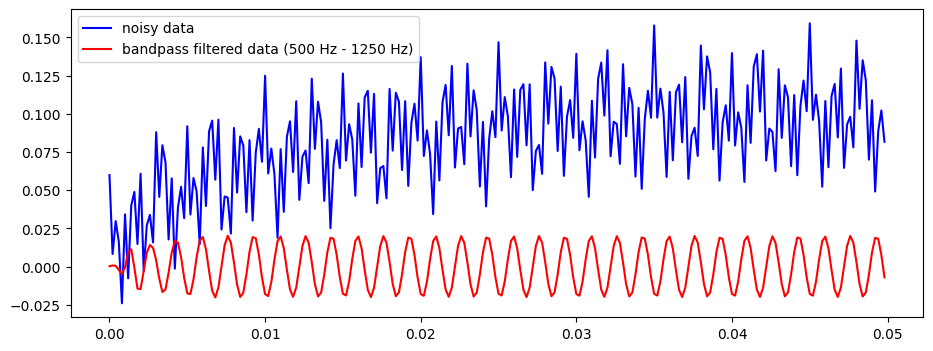

In [8]:
# make a plot

plt.figure(figsize = (11,4))                  #specify figure size as 7 x 5 inches
                                             #for default size, type plt.figure() 

# plot original data 
plt.plot(t, x_noisy, color = 'blue', label = 'noisy data ')
plt.plot(t, x_filtered,  color = 'red', label = 'bandpass filtered data (%g Hz - %g Hz)' % (low_pass,high_pass ))
plt.legend(loc = "best")
plt.show()

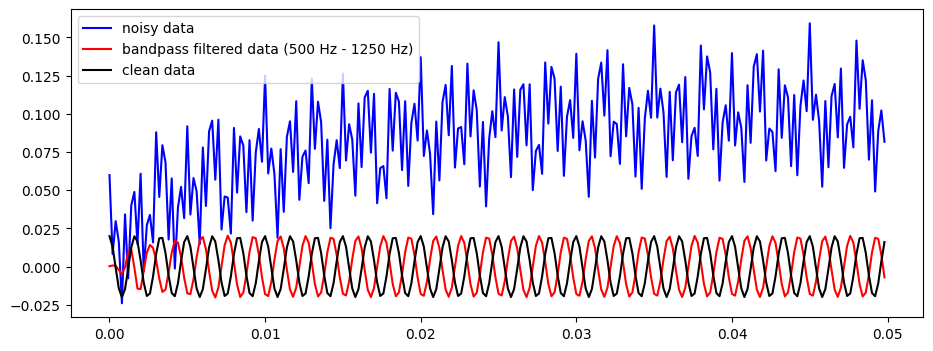

In [9]:
# make a plot

plt.figure(figsize = (11,4))                  #specify figure size as 7 x 5 inches
                                             #for default size, type plt.figure() 

# plot original data 
plt.plot(t, x_noisy, color = 'blue', label = 'noisy data ')
plt.plot(t, x_filtered,  color = 'red', label = 'bandpass filtered data (%g Hz - %g Hz)' % (low_pass,high_pass ))
plt.plot(t, x_clean, color = 'black', label = 'clean data ')
plt.legend(loc = "best")
plt.show()

### Assignment 

```{exercise}Band-Pass-Filter-Exercise
:label:Band-Pass-Filter-Exercise


1. Why do we no longer see the slow background variation in the data (initial rise from 0.025 to 0.100 vertically)?
2. Why is the amplitude of the signal initially time dependent (between t = 0 and 0.01)  after passing through the filter?
3. Why is there a phase shift (delay) in the filtered signal? 
```

## test out your theory! 
try different low pass and high pass cutoff frequencies 

In [10]:
low_pass = 400.0 # Hz
high_pass = 900.0 # Hz

In [11]:
# "Butterworth" bandpass filter of data 
x_filtered = butter_bandpass_filter(x_noisy, low_pass, high_pass, f_sampling, order=6)

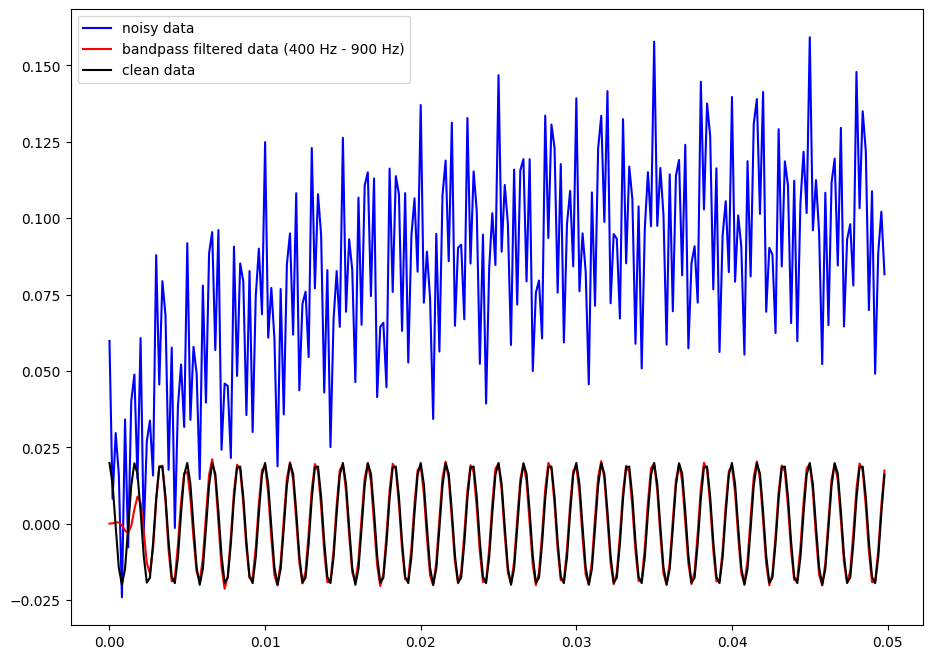

In [12]:
# make a plot

plt.figure(figsize = (11,8))                  #specify figure size as 7 x 5 inches
                                             #for default size, type plt.figure() 

# plot original data 
plt.plot(t, x_noisy, color = 'blue', label = 'noisy data ')
plt.plot(t, x_filtered,  color = 'red', label = 'bandpass filtered data (%g Hz - %g Hz)' % (low_pass,high_pass ))
plt.plot(t, x_clean, color = 'black', label = 'clean data ')
plt.legend(loc = "best")
plt.show()

## apply Butterworth band pass filter to new set of noisy data


### create noisy signal

In [13]:
# Generate a noisy signal to be filtered. Leave this unchanged
new_f_max = 10000
new_f_signal = 600
T = 0.01
nsamples = int(T * new_f_max)
t = np.linspace(0, T, nsamples, endpoint=False)

x_new = (np.sin(2 * np.pi * new_f_signal * t + 2.1)) 
x_new_noisy = x_new + (rng.random(len(t))-0.5) * 1 # random number is between 0 and 1, so subtract off 0.5 to all + and - values

print(t[1] - t[0] )




0.0001


### adjust bandpass filter

#### change these parameters

In [14]:
# vary multiplicative_factor and filter order to find best tradeoff between degree of filtering and duration of initial transient response (delay)
multiplicative_factor =5  # must be larger than 1 and smaller than 8
filter_order = 6

#### run this code

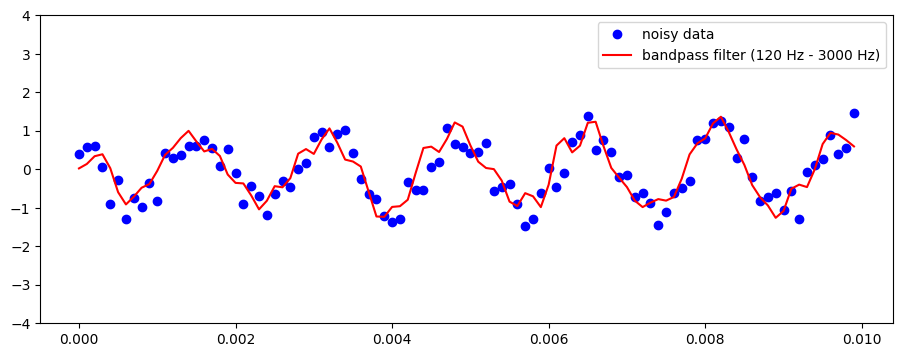

In [15]:
# "Butterworth" bandpass filter of data 

new_low_pass = new_f_signal / multiplicative_factor
new_high_pass = new_f_signal * multiplicative_factor
x_new_filtered = butter_bandpass_filter(x_new_noisy, new_low_pass, new_high_pass, new_f_max, order=filter_order)

# make a plot of results

plt.figure(figsize = (11, 4))                  #specify figure size as 7 x 5 inches
                                             #for default size, type plt.figure() 

# plot original data 
#plt.plot(t, x_new, color = 'black', linewidth = 0.5,  label = 'original data')
# plt.plot(t, x_new_noisy,  color = 'blue', label = 'noisy data ')
plt.plot(t, x_new_noisy, "o",  color = 'blue', label = 'noisy data ')
plt.plot(t, x_new_filtered,  color = 'red', label = 'bandpass filter (%g Hz - %g Hz)' % (new_low_pass,new_high_pass ))
plt.legend(loc = "best")
#plt.xlim(0, 5*T)
plt.ylim(-4,4)
plt.show()

### Assignment 

```{exercise}
:label: Adjust-Band-Pass-Parameters

try out different values for the low pass and high pass cutoffs for the bandpass filter, leaving the filter centered on the signal frequency of 600 Hz. You can do this by varying the value of the parameter ```multiplicative_factor``` in the code cell directly below this one. 

1. What is your recommended 'best value' for the bandpass range for this 6th order filter, and why? 

2. Repeat these tasks for a 2nd order filter. 

- what is your recommended 'best value' for the bandpass range? 
- Do you need a higher or lower multiplicative factor to get the same results as before? 
- is the duration of the transient response shorter or longer? 
```
                                                        


## assignment submission 

Submit answers to both exercises!

This is a lab analysis notebook, so 

1. Create a new notebook for this assignment.
2. Add your name to the assignment.
3. Give the notebook a new file name.

General guidance: 
- You may copy from this notebook any Python code you need but **do not** include the introductory text.
- Instead, replace these examples with your own data smoothing results (for polynomial order $n = 3$)
- as always, be sure the notebook can run without error if you select ```Restart Kernel and Run all Cells``` from the Kernel menu. 
